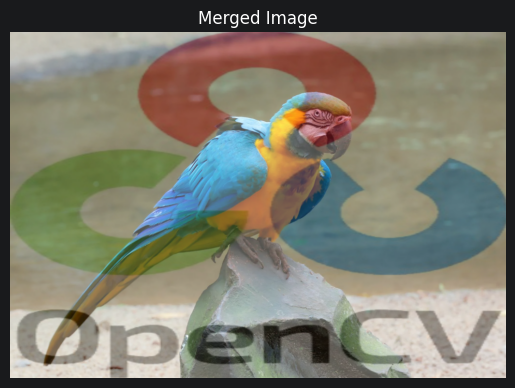

In [1]:
import cv2
import os
import matplotlib.pyplot as plt

# đọc ảnh
img1 = cv2.imread(os.path.join('.', 'img_data', 'anhchim2.png'))
img2 = cv2.imread(os.path.join('.', 'img_data', 'logo.png'))

# resize
h, w = img1.shape[:2]
img2 = cv2.resize(img2, (w, h))

# ghép ảnh
dst = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

# convert BGR -> RGB (RẤT QUAN TRỌNG)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
dst_rgb  = cv2.cvtColor(dst,  cv2.COLOR_BGR2RGB)

# hiển thị
plt.imshow(dst_rgb)
plt.title("Merged Image")
plt.axis('off')
plt.show()

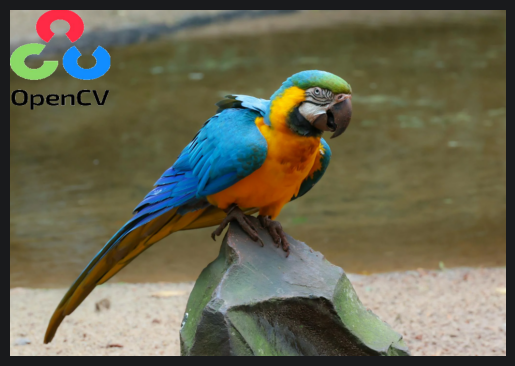

In [4]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh
img1 = cv2.imread(os.path.join('.', 'img_data', 'anhchim2.png'))
img2 = cv2.imread(os.path.join('.', 'img_data', 'logo.png'))

# resize logo
img2 = cv2.resize(img2, (200, 200))

rows, cols, _ = img2.shape

# ROI
roi = img1[0:rows, 0:cols]

# ===== tạo mask bỏ nền trắng =====
# nền trắng ~ [255,255,255]
lower = np.array([200, 200, 200])
upper = np.array([255, 255, 255])

mask_white = cv2.inRange(img2, lower, upper)   # vùng trắng
mask = cv2.bitwise_not(mask_white)             # giữ logo

# ===== background (xóa chỗ logo trên ảnh chim)
img1_bg = cv2.bitwise_and(roi, roi, mask=mask_white)

# ===== foreground (lấy logo)
img2_fg = cv2.bitwise_and(img2, img2, mask=mask)

# ===== ghép
dst = cv2.add(img1_bg, img2_fg)
img1[0:rows, 0:cols] = dst

# convert BGR -> RGB (cho Jupyter)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

# show
plt.imshow(img1_rgb)
plt.axis('off')
plt.show()

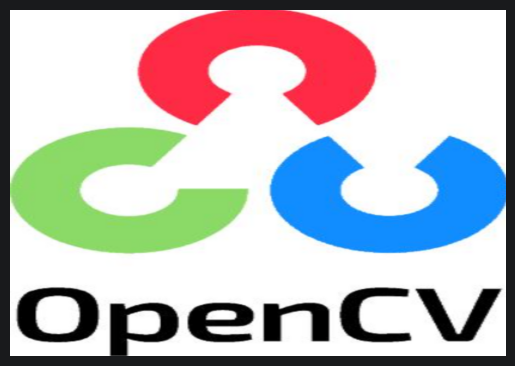

In [11]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 📂 thư mục ảnh
folder = os.path.join('.', 'img_data')

# lấy danh sách ảnh
image_files = sorted(os.listdir(folder))

images = []

# đọc ảnh
for file in image_files:
    path = os.path.join(folder, file)
    img = cv2.imread(path)
    if img is not None:
        images.append(img)

# resize tất cả về cùng size (theo ảnh đầu)
h, w = images[0].shape[:2]
images = [cv2.resize(img, (w, h)) for img in images]

# 🔥 slideshow
#while True:  # chạy lặp vô hạn (giống trình chiếu)
for i in range(len(images) - 1):
    img1 = images[i]
    img2 = images[i + 1]

    # transition
    for alpha in np.linspace(0, 1, 30):
        dst = cv2.addWeighted(img1, 1-alpha, img2, alpha, 0)

        dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

        clear_output(wait=True)
        plt.imshow(dst_rgb)
        plt.axis('off')
        plt.show()